In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from pytorch_msssim import ssim as ssim_loss
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)  # should print 'cuda'

cuda


In [3]:
DATASET_DIR = 'D:/DL_slices'
inputs_path  = os.path.join(DATASET_DIR, 'dataset_inputs.npy')
targets_path = os.path.join(DATASET_DIR, 'dataset_targets.npy')

In [4]:
class MRISliceDataset(Dataset):
    def __init__(self, inputs_path, targets_path, indices=None):
        # Memory-mapped: only loads individual slices on demand, not the whole file
        self.inputs  = np.load(inputs_path,  mmap_mode='r')
        self.targets = np.load(targets_path, mmap_mode='r')
        self.indices = indices if indices is not None else np.arange(len(self.inputs))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        x = torch.tensor(np.array(self.inputs[real_idx]),  dtype=torch.float32)  # (2, 256, 256)
        y = torch.tensor(np.array(self.targets[real_idx]), dtype=torch.float32).unsqueeze(0)  # (1, 256, 256)
        return x, y

# Split by indices — avoids loading full array into RAM
total = len(np.load(inputs_path, mmap_mode='r'))
print(f"Total pairs: {total:,}")

np.random.seed(42)
all_indices = np.random.permutation(total)
n_train     = int(0.70 * total)
n_val       = int(0.15 * total)

train_indices = all_indices[:n_train]
val_indices   = all_indices[n_train:n_train + n_val]
test_indices  = all_indices[n_train + n_val:]

train_set = MRISliceDataset(inputs_path, targets_path, train_indices)
val_set   = MRISliceDataset(inputs_path, targets_path, val_indices)
test_set  = MRISliceDataset(inputs_path, targets_path, test_indices)

BATCH_SIZE = 8

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train : {len(train_set):>7,} pairs")
print(f"Val   : {len(val_set):>7,} pairs")
print(f"Test  : {len(test_set):>7,} pairs")

Total pairs: 42,816
Train :  29,971 pairs
Val   :   6,422 pairs
Test  :   6,423 pairs


In [5]:
class ConvBlock(nn.Module):
    """Two conv layers with batch norm and ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Small U-Net for MRI slice interpolation.
    Input  : (B, 2, 256, 256)  — two neighboring slices
    Output : (B, 1, 256, 256)  — predicted intermediate slice
    """
    def __init__(self, in_channels=2, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────
        self.encoders  = nn.ModuleList()
        self.pools     = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(ConvBlock(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        # ── Bottleneck ────────────────────────────────────────
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        # ── Decoder ──────────────────────────────────────────
        self.upconvs   = nn.ModuleList()
        self.decoders  = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2))
            self.decoders.append(ConvBlock(f * 2, f))
            ch = f

        # ── Output head ──────────────────────────────────────
        self.output_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        self.sigmoid     = nn.Sigmoid()   # output in [0, 1] to match normalized inputs

    def forward(self, x):
        # Encoder — save skip connections
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        # Decoder — upsample and concatenate skip connections
        for upconv, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.sigmoid(self.output_conv(x))


model = UNet().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters : {total_params:,}")

U-Net parameters : 7,762,753


In [6]:
class CombinedLoss(nn.Module):
    """
    Weighted combination of L1 (pixel accuracy) and
    SSIM loss (structural similarity).
    loss = alpha * L1 + (1 - alpha) * (1 - SSIM)
    """
    def __init__(self, alpha=0.8):
        super().__init__()
        self.alpha  = alpha
        self.l1     = nn.L1Loss()

    def forward(self, pred, target):
        l1_loss   = self.l1(pred, target)
        ssim_val  = ssim_loss(pred, target, data_range=1.0, size_average=True)
        ssim_loss_ = 1 - ssim_val
        return self.alpha * l1_loss + (1 - self.alpha) * ssim_loss_

criterion = CombinedLoss(alpha=0.8)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


NUM_EPOCHS  = 20
SAVE_PATH  = os.path.join(DATASET_DIR, 'unet_best.pth')
best_val    = float('inf')

history = {'train_loss': [], 'val_loss': []}

print(f"Training for {NUM_EPOCHS} epochs on {DEVICE}...\n")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print("-" * 50)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss   = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | {lr:>10.2e}")

    # Save best model
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"         >> Best model saved (val_loss={best_val:.6f})")

print(f"\nTraining complete. Best val loss: {best_val:.6f}")

Training for 20 epochs on cuda...

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
     1 |     0.042004 |     0.023895 |   1.00e-03
         >> Best model saved (val_loss=0.023895)
     2 |     0.023895 |     0.021239 |   1.00e-03
         >> Best model saved (val_loss=0.021239)
     3 |     0.022341 |     0.020838 |   1.00e-03
         >> Best model saved (val_loss=0.020838)
     4 |     0.021588 |     0.020668 |   1.00e-03
         >> Best model saved (val_loss=0.020668)
     5 |     0.020879 |     0.023558 |   1.00e-03
     6 |     0.020456 |     0.019918 |   1.00e-03
         >> Best model saved (val_loss=0.019918)
     7 |     0.020145 |     0.020790 |   1.00e-03
     8 |     0.020066 |     0.022871 |   1.00e-03
     9 |     0.019948 |     0.020417 |   1.00e-03
    10 |     0.019885 |     0.021240 |   1.00e-03
    11 |     0.019845 |     0.019389 |   1.00e-03
         >> Best model saved (val_loss=0.019389)
    12 |     0.01979

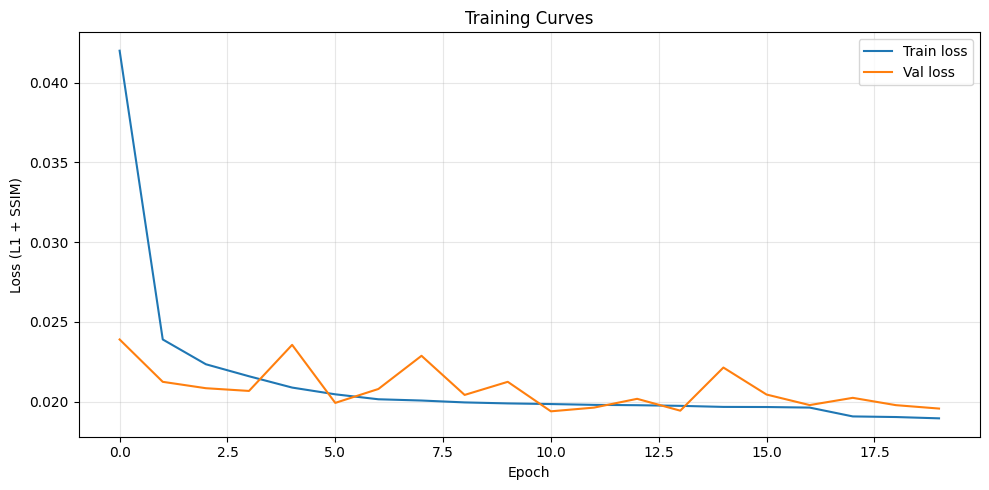

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train loss', linewidth=1.5)
ax.plot(history['val_loss'],   label='Val loss',   linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (L1 + SSIM)')
ax.set_title('Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
def evaluate_test_set(model, loader, device):
    model.eval()
    psnr_scores, ssim_scores, mae_scores = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x    = x.to(device)
            pred = model(x).cpu().numpy()       # (B, 1, 256, 256)
            gt   = y.numpy()                    # (B, 1, 256, 256)

            for i in range(len(pred)):
                p = pred[i, 0]                  # (256, 256)
                g = gt[i, 0]

                psnr_scores.append(psnr(g, p, data_range=1.0))
                ssim_scores.append(ssim(g, p, data_range=1.0))
                mae_scores.append(np.mean(np.abs(g - p)))

    return {
        'psnr_mean': np.mean(psnr_scores), 'psnr_std': np.std(psnr_scores),
        'ssim_mean': np.mean(ssim_scores), 'ssim_std': np.std(ssim_scores),
        'mae_mean' : np.mean(mae_scores),  'mae_std' : np.std(mae_scores),
        'per_sample_psnr': psnr_scores,
        'per_sample_ssim': ssim_scores,
        'per_sample_mae' : mae_scores,
    }

# Load best model for evaluation
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
metrics = evaluate_test_set(model, test_loader, DEVICE)

print("\n========== TEST SET RESULTS ==========")
print(f"{'Metric':<10} {'Mean':>10} {'Std':>10}")
print("-" * 32)
print(f"{'PSNR':<10} {metrics['psnr_mean']:>9.2f}dB {metrics['psnr_std']:>9.2f}")
print(f"{'SSIM':<10} {metrics['ssim_mean']:>10.4f} {metrics['ssim_std']:>10.4f}")
print(f"{'MAE':<10} {metrics['mae_mean']:>10.5f} {metrics['mae_std']:>10.5f}")



========== TEST SET RESULTS ==========
Metric           Mean        Std
--------------------------------
PSNR           35.95dB      6.54
SSIM           0.9455     0.0294
MAE           0.00939    0.00527


In [10]:
baseline_linear = {'psnr': 33.21, 'ssim': 0.9066, 'mae': None}
baseline_spline = {'psnr': 33.19, 'ssim': 0.9048, 'mae': None}

print("\n========== U-NET vs BASELINES ==========")
print(f"{'Method':<20} {'PSNR (dB)':>10} {'SSIM':>10} {'MAE':>10}")
print("-" * 54)
print(f"{'Linear Interp.':<20} {baseline_linear['psnr']:>10.2f} {baseline_linear['ssim']:>10.4f} {'N/A':>10}")
print(f"{'Cubic Spline':<20} {baseline_spline['psnr']:>10.2f} {baseline_spline['ssim']:>10.4f} {'N/A':>10}")
print(f"{'U-Net (ours)':<20} {metrics['psnr_mean']:>10.2f} {metrics['ssim_mean']:>10.4f} {metrics['mae_mean']:>10.5f}")

improvement_psnr = metrics['psnr_mean'] - baseline_linear['psnr']
improvement_ssim = metrics['ssim_mean'] - baseline_linear['ssim']
print(f"\n  Improvement over linear: PSNR {improvement_psnr:+.2f} dB  |  SSIM {improvement_ssim:+.4f}")


========== U-NET vs BASELINES ==========
Method                PSNR (dB)       SSIM        MAE
------------------------------------------------------
Linear Interp.            33.21     0.9066        N/A
Cubic Spline              33.19     0.9048        N/A
U-Net (ours)              35.95     0.9455    0.00939

  Improvement over linear: PSNR +2.74 dB  |  SSIM +0.0389


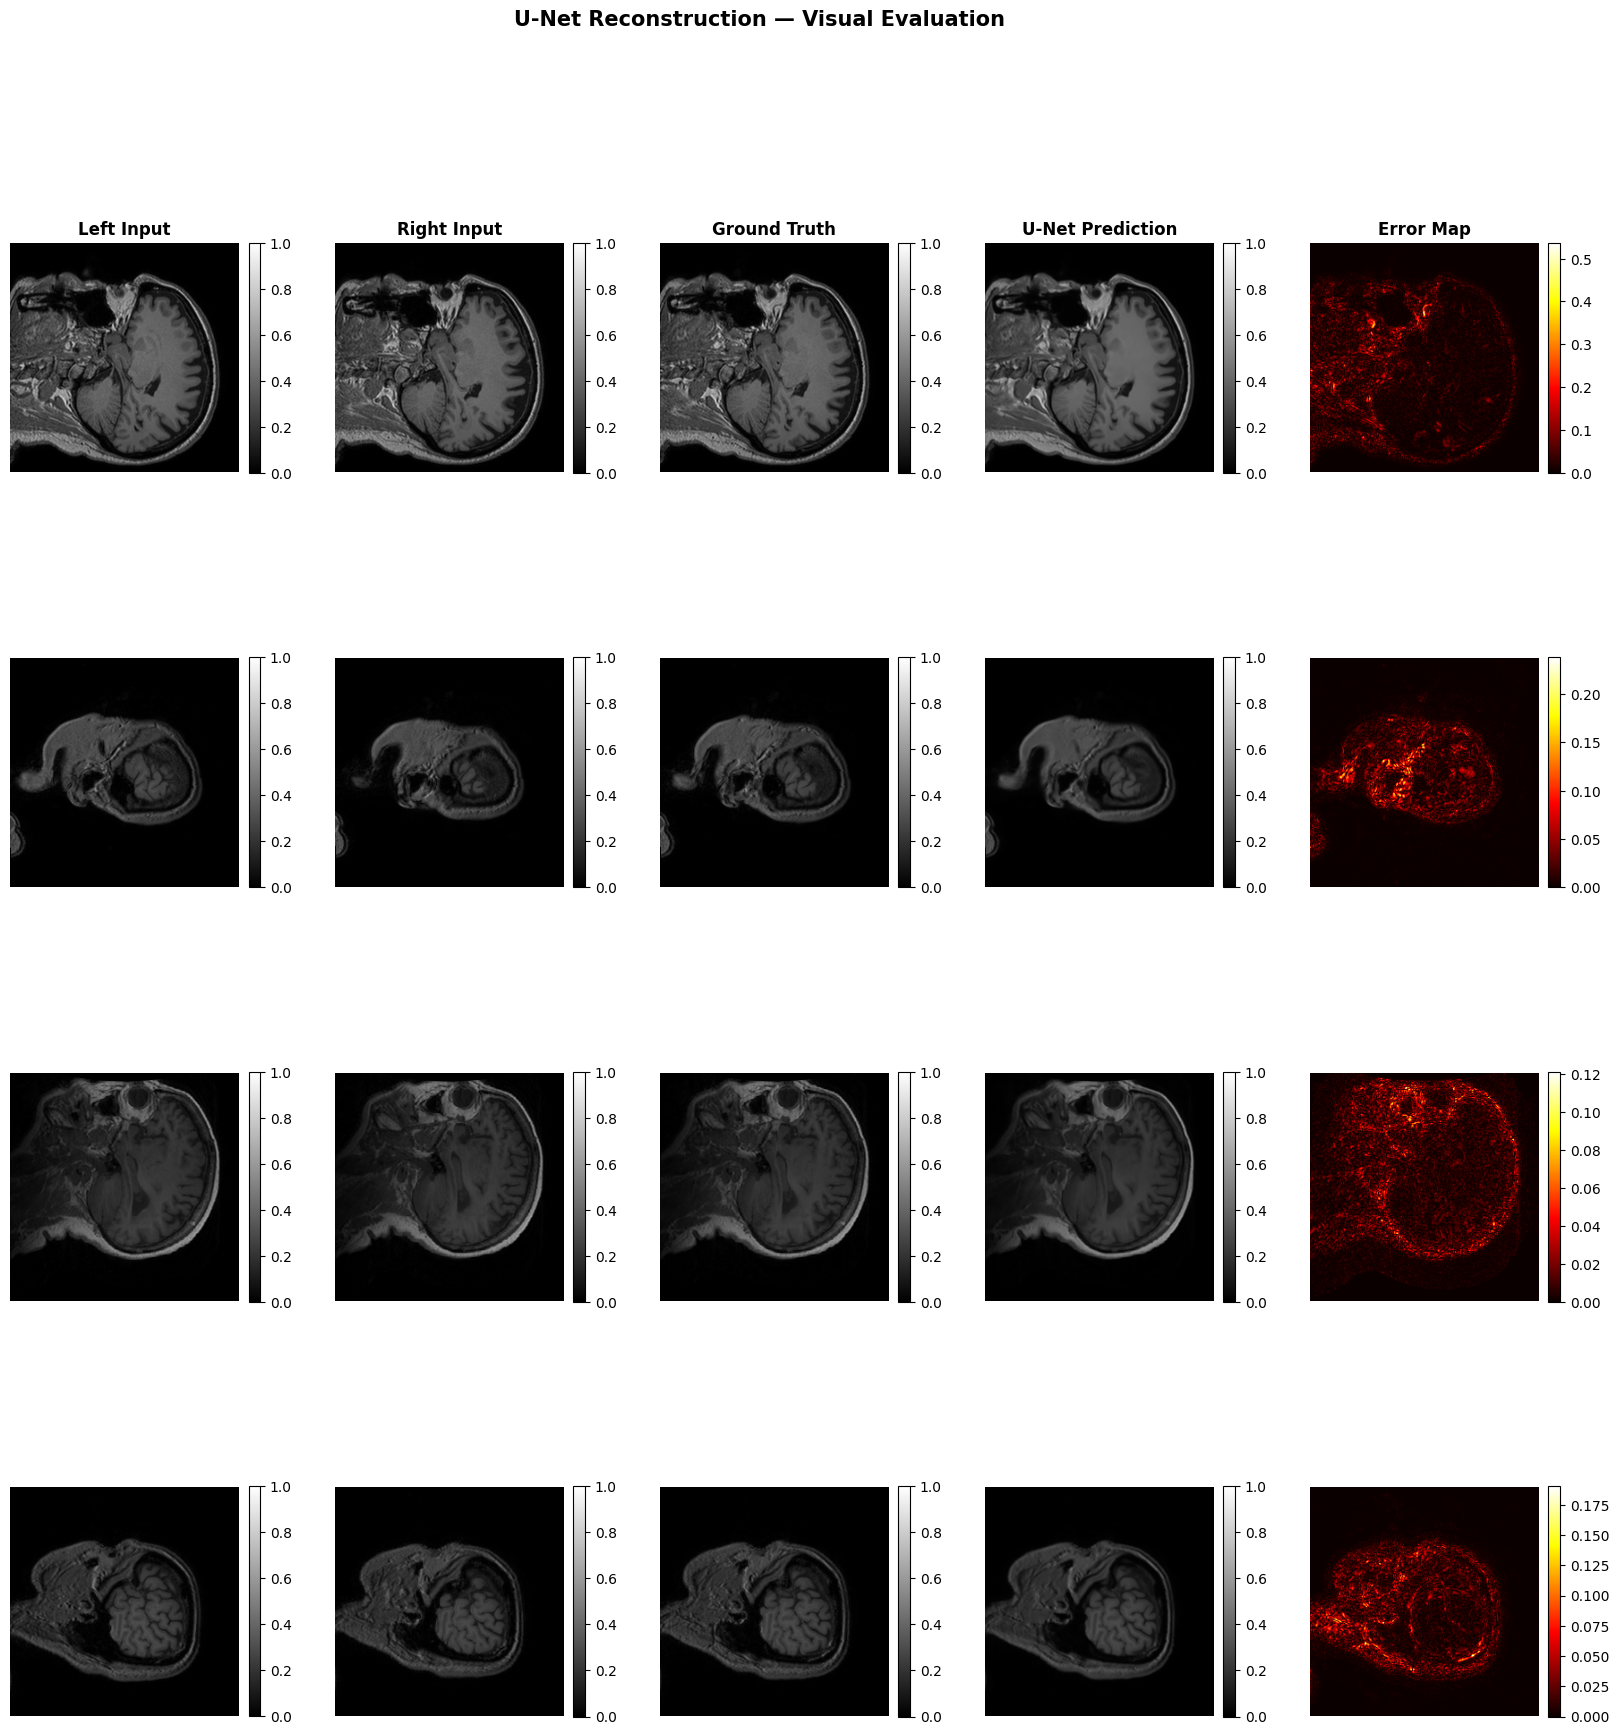

In [11]:
def visualize_predictions(model, dataset, device, n_samples=4, seed=42):
    model.eval()
    rng     = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), n_samples, replace=False)

    fig = plt.figure(figsize=(20, 5 * n_samples))
    gs  = gridspec.GridSpec(n_samples, 5, figure=fig, hspace=0.4, wspace=0.3)

    col_titles = ['Left Input', 'Right Input', 'Ground Truth', 'U-Net Prediction', 'Error Map']

    for row, idx in enumerate(indices):
        x, y   = dataset[idx]
        with torch.no_grad():
            pred = model(x.unsqueeze(0).to(device)).squeeze().cpu().numpy()

        left   = x[0].numpy()
        right  = x[1].numpy()
        gt     = y[0].numpy()
        error  = np.abs(gt - pred)

        imgs   = [left, right, gt, pred, error]
        cmaps  = ['gray', 'gray', 'gray', 'gray', 'hot']
        vmins  = [0, 0, 0, 0, 0]
        vmaxs  = [1, 1, 1, 1, error.max()]

        sample_psnr = psnr(gt, pred, data_range=1.0)
        sample_ssim = ssim(gt, pred, data_range=1.0)
        sample_mae  = np.mean(error)

        for col, (img, cmap, vmin, vmax, title) in enumerate(
                zip(imgs, cmaps, vmins, vmaxs, col_titles)):
            ax = fig.add_subplot(gs[row, col])
            im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            if row == 0:
                ax.set_title(title, fontsize=12, fontweight='bold')
            if col == 3:
                ax.set_xlabel(
                    f"PSNR={sample_psnr:.1f}dB  SSIM={sample_ssim:.3f}  MAE={sample_mae:.4f}",
                    fontsize=9
                )
            ax.axis('off')

    fig.suptitle('U-Net Reconstruction — Visual Evaluation', fontsize=15, fontweight='bold')
    plt.show()

visualize_predictions(model, test_set, DEVICE, n_samples=4)

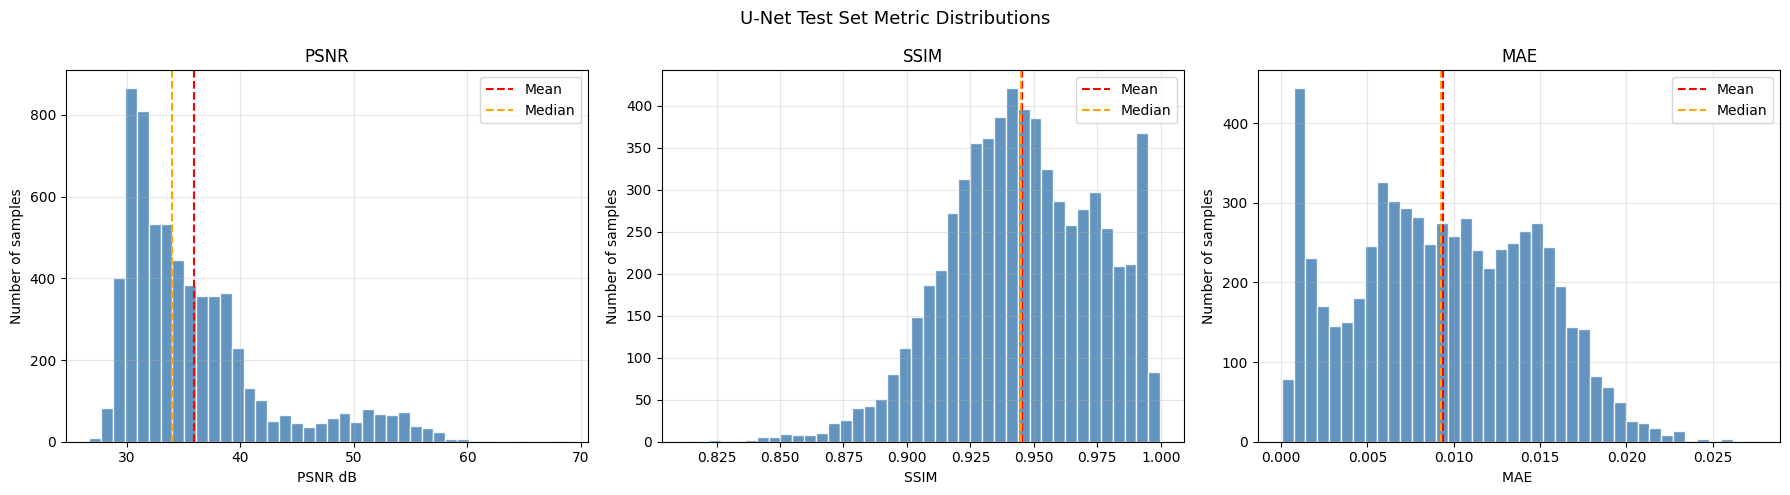

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('U-Net Test Set Metric Distributions', fontsize=13)

for ax, (scores, label, unit) in zip(axes, [
    (metrics['per_sample_psnr'], 'PSNR', 'dB'),
    (metrics['per_sample_ssim'], 'SSIM', ''),
    (metrics['per_sample_mae'],  'MAE',  ''),
]):
    ax.hist(scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(scores), color='red',    linestyle='--', linewidth=1.5, label=f'Mean')
    ax.axvline(np.median(scores), color='orange', linestyle='--', linewidth=1.5, label=f'Median')
    ax.set_xlabel(f'{label} {unit}')
    ax.set_ylabel('Number of samples')
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
np.save('D:/DL_slices/unet_test_metrics.npy', metrics)
print("Metrics saved.")


Metrics saved.
